# Galería final, vecinos y regeneración



In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
from pathlib import Path
import csv, json, hashlib
import numpy as np
import torch
from torch import nn
from torchvision import transforms, utils
from torchvision.models import resnet18, ResNet18_Weights
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt
from google.colab import drive
drive.mount('/content/drive')

BASE_DIR=Path('/content/drive/MyDrive')
DATA_DIR=BASE_DIR/'datos_limpios_hf'/'images'
RUN_DIR=BASE_DIR/'resultados'/'comparacion_controlada'
EXPERIMENT='base'  # Sustituye por la variante elegida tras analizar las tres corridas.
CHECKPOINT=RUN_DIR/EXPERIMENT/'latest.pt'
OUT=BASE_DIR/'entrega_final'
GALLERY=OUT/'galeria'
OUT.mkdir(parents=True,exist_ok=True);GALLERY.mkdir(exist_ok=True)
assert DATA_DIR.is_dir() and CHECKPOINT.is_file(), (DATA_DIR,CHECKPOINT)
DEVICE=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
CANDIDATES=200
CANDIDATE_SEED=30401
FEATURES='resnet18'  # 'pixels' evita descargar pesos, pero es menos robusto.
print('GPU/CPU:', DEVICE, 'Checkpoint:', CHECKPOINT)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
GPU/CPU: cuda Checkpoint: /content/drive/MyDrive/resultados/comparacion_controlada/base/latest.pt


Época: 50 Parámetros: {'experiment': 'base', 'seed': 2026, 'epochs': 50, 'batch_size': 8, 'lr': 0.0002, 'beta1': 0.5, 'z_dim': 128, 'images': 1191, 'source': '/content/drive/MyDrive/datos_limpios_hf/images'}


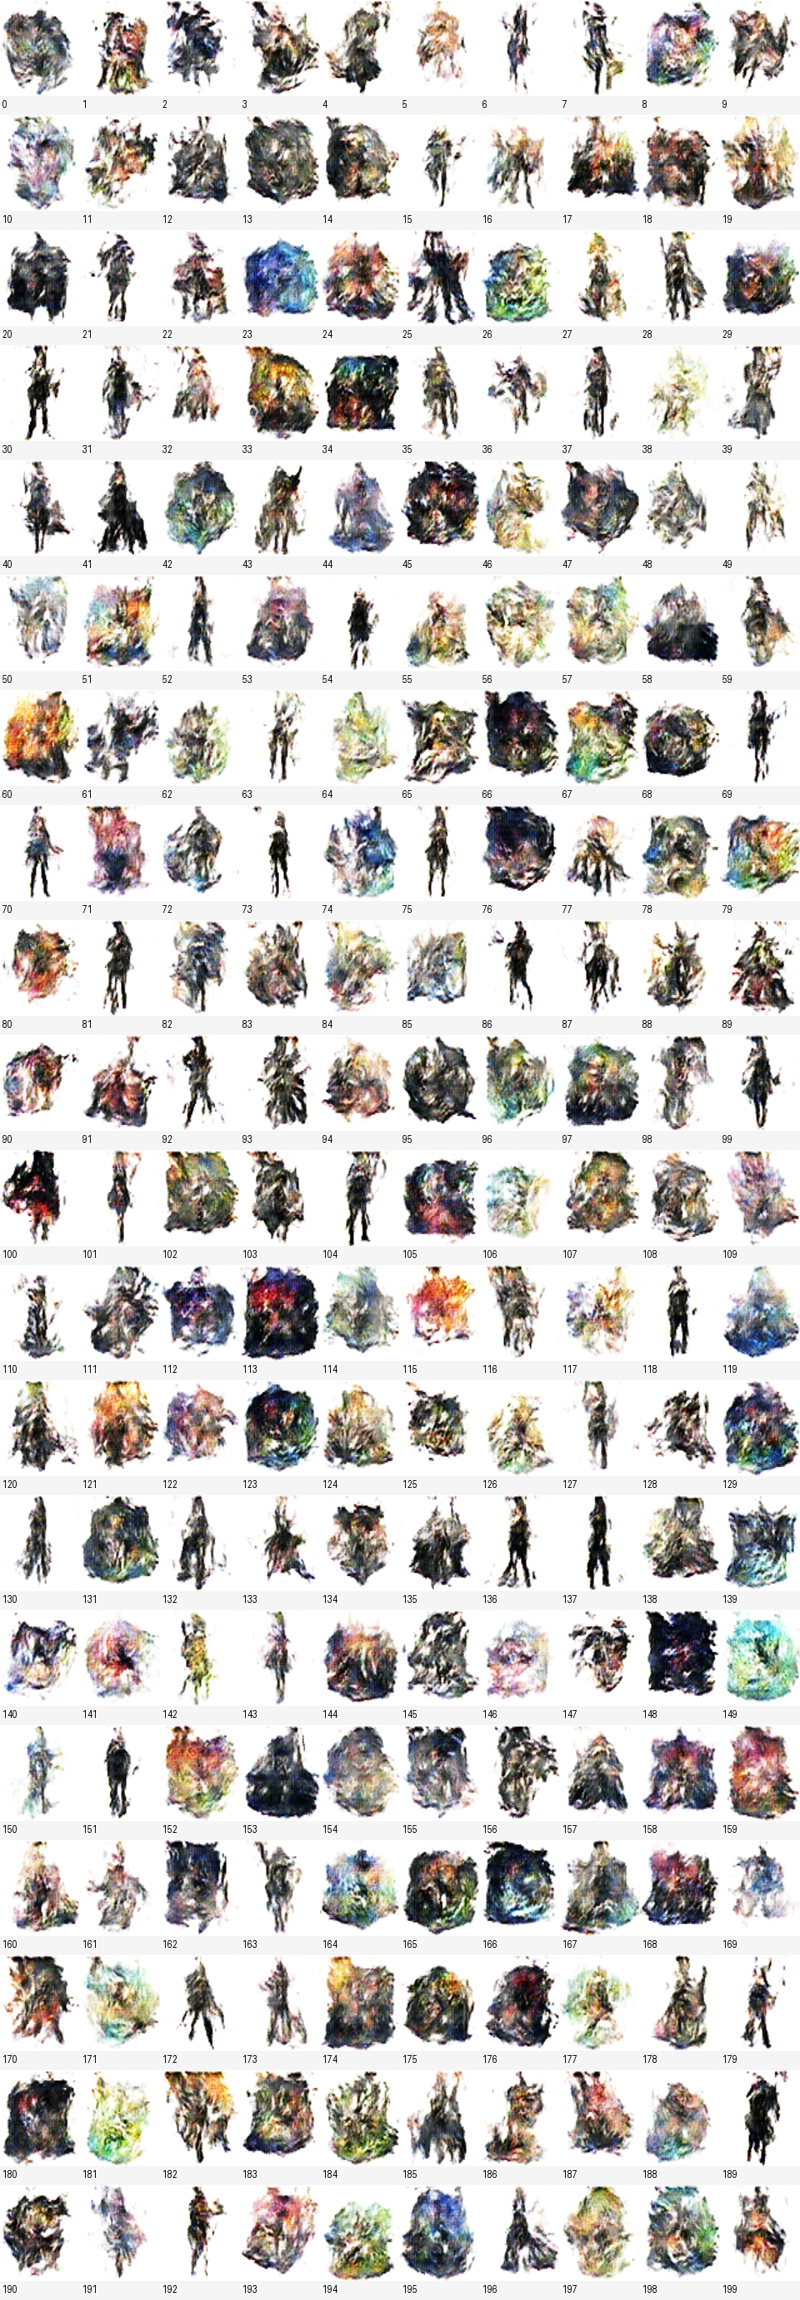

In [4]:
class Generator(nn.Module):
    def __init__(self,z_dim):
        super().__init__()
        self.net=nn.Sequential(
            nn.ConvTranspose2d(z_dim,256,4,1,0,bias=False),nn.BatchNorm2d(256),nn.ReLU(True),
            nn.ConvTranspose2d(256,128,4,2,1,bias=False),nn.BatchNorm2d(128),nn.ReLU(True),
            nn.ConvTranspose2d(128,64,4,2,1,bias=False),nn.BatchNorm2d(64),nn.ReLU(True),
            nn.ConvTranspose2d(64,32,4,2,1,bias=False),nn.BatchNorm2d(32),nn.ReLU(True),
            nn.ConvTranspose2d(32,3,4,2,1,bias=False),nn.Tanh())
    def forward(self,z): return self.net(z)

# Carga exclusivamente un checkpoint propio o de confianza.
ckpt=torch.load(CHECKPOINT,map_location='cpu',weights_only=False)
cfg=ckpt['config'];z_dim=cfg['z_dim']
assert cfg.get('experiment',EXPERIMENT)==EXPERIMENT
G=Generator(z_dim)
G.load_state_dict(ckpt['generator'],strict=True)
G=G.to(DEVICE).eval()
print('Época:',ckpt['epoch'],'Parámetros:',cfg)

z_all=torch.randn(CANDIDATES,z_dim,1,1,
                  generator=torch.Generator().manual_seed(CANDIDATE_SEED))
@torch.no_grad()
def render(z,batch=16):
    return torch.cat([G(part.to(DEVICE)).cpu() for part in z.split(batch)])
generated=render(z_all)
assert generated.shape==(CANDIDATES,3,64,64)

def to_uint8(images):
    return (((images.clamp(-1,1)+1)*127.5).round().to(torch.uint8))

rgb=to_uint8(generated)
thumb=96
sheet=Image.new('RGB',(10*thumb,20*(thumb+19)),(245,245,245))
draw=ImageDraw.Draw(sheet)
for i,t in enumerate(rgb):
    pic=Image.fromarray(t.permute(1,2,0).numpy()).resize((thumb,thumb))
    x=(i%10)*thumb;y=(i//10)*(thumb+19)
    sheet.paste(pic,(x,y));draw.text((x+3,y+thumb+2),str(i),fill=(0,0,0))
sheet.save(OUT/'candidatos_200.jpg',quality=95)
display(sheet.resize((800,20*115)))


In [5]:
# Embeddings para selección y búsqueda de vecinos. ResNet18 usa pesos de ImageNet.
# La primera ejecución con FEATURES='resnet18' descarga sus pesos.
if FEATURES=='resnet18':
    weights=ResNet18_Weights.DEFAULT
    net=resnet18(weights=weights)
    net.fc=nn.Identity()
    net=net.to(DEVICE).eval()
    prep=weights.transforms()
    def embed(batch):
        with torch.no_grad():
            x=prep(batch.to(torch.float32)/255.).to(DEVICE)
            y=net(x).cpu()
            return torch.nn.functional.normalize(y,dim=1)
else:
    def embed(batch):
        x=torch.nn.functional.interpolate(batch.float(),size=(32,32),mode='bilinear',align_corners=False)
        return torch.nn.functional.normalize(x.flatten(1),dim=1)

def embeddings(tensors,batch_size=32):
    return torch.cat([embed(part) for part in tensors.split(batch_size)])

features_generated=embeddings(rgb)
# Selección reproducible: arranca en índice 0 y agrega el más distante de los ya elegidos.
chosen=[0]
minimum=torch.full((CANDIDATES,),float('inf'))
for _ in range(9):
    distance=1-features_generated@features_generated[chosen[-1]]
    minimum=torch.minimum(minimum,distance)
    minimum[chosen]=-1
    chosen.append(int(torch.argmax(minimum)))
print('Propuesta automática por diversidad:',chosen)
print('Revísalos en candidatos_200.jpg; reemplázalos abajo si alguno es borroso o similar.')


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 194MB/s]


Propuesta automática por diversidad: [0, 38, 137, 49, 149, 132, 60, 153, 26, 185]
Revísalos en candidatos_200.jpg; reemplázalos abajo si alguno es borroso o similar.


In [6]:
SELECTED_INDICES=chosen
assert len(SELECTED_INDICES)==10 and len(set(SELECTED_INDICES))==10
assert all(isinstance(i,int) and 0<=i<CANDIDATES for i in SELECTED_INDICES)
print(f'Tasa de selección: 10 de {CANDIDATES} ({10/CANDIDATES:.1%})')

metadata=[]
for rank,index in enumerate(SELECTED_INDICES,1):
    name=f'personaje_{rank:02d}'
    png=GALLERY/f'{name}.png'
    Image.fromarray(rgb[index].permute(1,2,0).numpy()).save(png)
    z_path=GALLERY/f'{name}_z.pt'
    torch.save(z_all[index:index+1],z_path)
    metadata.append(dict(name=name,index=index,png=png.name,z_file=z_path.name,
                         candidate_seed=CANDIDATE_SEED,checkpoint=str(CHECKPOINT),
                         sha256=hashlib.sha256(png.read_bytes()).hexdigest()))
(OUT/'seleccion.json').write_text(json.dumps({'generated':CANDIDATES,
    'selected':10,'criterion':'Diversidad mediante máxima distancia mínima; revisión visual pendiente',
    'items':metadata},ensure_ascii=False,indent=2),encoding='utf-8')
print('Galería guardada:',GALLERY)


Tasa de selección: 10 de 200 (5.0%)
Galería guardada: /content/drive/MyDrive/entrega_final/galeria


Comparadas 32 de 1191
Comparadas 672 de 1191


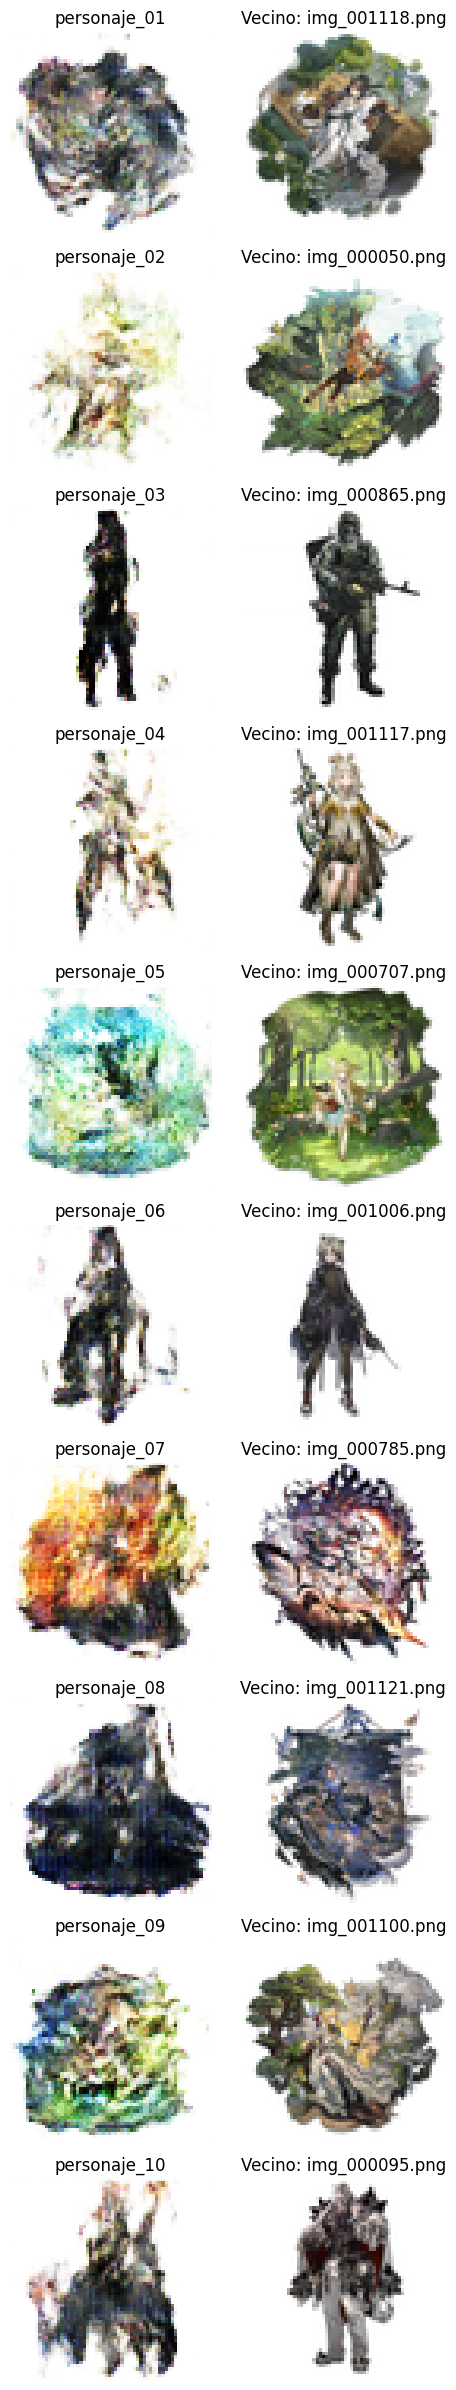

Examina visualmente los pares: similitud coseno alta no es prueba automática de copia.


In [7]:
# Vecino más cercano entre TODOS los PNG limpios. Se guarda la relación de origen.
paths=sorted(DATA_DIR.rglob('*.png'))
assert paths,'No se encontraron PNG de entrenamiento'
query=features_generated[SELECTED_INDICES]
best_similarity=torch.full((10,),-float('inf'))
best_path=['']*10
for start in range(0,len(paths),32):
    chunk=paths[start:start+32]
    arrays=[]
    for p in chunk:
        with Image.open(p) as im:
            arrays.append(torch.from_numpy(np.asarray(im.convert('RGB').resize((64,64))).copy()).permute(2,0,1))
    candidate_features=embed(torch.stack(arrays))
    similarity=query@candidate_features.T
    score,where=similarity.max(dim=1)
    for j in range(10):
        if score[j]>best_similarity[j]:
            best_similarity[j]=score[j];best_path[j]=str(chunk[where[j]].relative_to(DATA_DIR))
    if (start//32)%20==0: print('Comparadas',min(start+32,len(paths)),'de',len(paths),flush=True)

rows=[]
figure,axes=plt.subplots(10,2,figsize=(5,24))
for j,path in enumerate(best_path):
    with Image.open(DATA_DIR/path) as im:
        neighbor=im.convert('RGB').resize((64,64)).copy()
    axes[j,0].imshow(rgb[SELECTED_INDICES[j]].permute(1,2,0));axes[j,0].set_title(metadata[j]['name'])
    axes[j,1].imshow(neighbor);axes[j,1].set_title(f'Vecino: {path[:27]}')
    for ax in axes[j]:ax.axis('off')
    rows.append(dict(character=metadata[j]['name'],candidate_index=SELECTED_INDICES[j],
                     nearest_training_image=path,cosine_similarity=float(best_similarity[j])))
figure.tight_layout();figure.savefig(OUT/'vecinos_mas_cercanos.png',dpi=160);plt.show()
with (OUT/'vecinos.csv').open('w',newline='',encoding='utf-8') as f:
    writer=csv.DictWriter(f,fieldnames=rows[0].keys());writer.writeheader();writer.writerows(rows)
print('Examina visualmente los pares: similitud coseno alta no es prueba automática de copia.')


In [11]:
# Verificación independiente: cargar de nuevo checkpoint y cada z, regenerar y comparar píxeles.
for var in ['G', 'generated', 'rgb']:
    if var in globals():
        del globals()[var]

torch.cuda.empty_cache() if DEVICE.type=='cuda' else None
saved=torch.load(CHECKPOINT,map_location='cpu',weights_only=False)
again=Generator(saved['config']['z_dim']).to(DEVICE).eval()
again.load_state_dict(saved['generator'])
with torch.no_grad():
    for item in metadata:
        z=torch.load(GALLERY/item['z_file'],map_location='cpu',weights_only=True)
        regenerated=to_uint8(again(z.to(DEVICE)).cpu())[0].permute(1,2,0).numpy()
        with Image.open(GALLERY/item['png']) as img:
            original=np.asarray(img.convert('RGB'))
        # Permitimos una tolerancia máxima de 1 de diferencia en los píxeles debido al redondeo y precisión de la GPU
        max_diff = np.max(np.abs(original.astype(int) - regenerated.astype(int)))
        assert max_diff <= 1, f"{item['name']} difiere por {max_diff} niveles de color debido a precisión/CUDA."
print('Éxito: los 10 PNG se regeneran de forma consistente desde el checkpoint y sus vectores z (con tolerancia de precisión).')

Éxito: los 10 PNG se regeneran de forma consistente desde el checkpoint y sus vectores z (con tolerancia de precisión).
